**Open h5 results file**

This code opens the h5 file and prints its structure, to make easier to find objects

In [ ]:
# Open h5 file and import necessary modules
import h5py

def inspect_h5_file(file_path):
    def print_structure(name, obj):
        # Evaluate needed identation based on the depth in the hierarchy
        indent = '  ' * name.count('/')

        if isinstance(obj, h5py.Group):
            print(f"{indent}Group: {name}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}Dataset: {name} - Shape: {obj.shape}, Dtype: {obj.dtype}")

            if obj.attrs:
                for attr_name, attr_value in obj.attrs.items():
                    print(f"{indent}  Attribute: {attr_name} = {attr_value}")

    print(f"Inspecting HDF5 file: {file_path}")
    with h5py.File(file_path, 'r') as h5file:
        h5file.visititems(print_structure)

# Example usage
file_path = r'output\20260209110723-1\optimization_results.h5'
inspect_h5_file(file_path)

In [1]:
from __future__ import annotations
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

def _to_scalar(x):
    """
    Convert dataset HDF5 to Python scalar if possible.
    Handles: scalars, 0-d arrays, 1-element arrays.
    """
    if isinstance(x, (np.generic,)):
        return float(x.item())
    x = np.asarray(x)
    if x.shape == ():          # 0-d
        return float(x.item())
    if x.size == 1:
        return float(x.reshape(-1)[0].item())
    return x  # if it's a real array (should not be for capex_tot)

def create_base_df(h5_path: str | Path,
                   year: str = "2022") -> pd.DataFrame:
    """
    Check structure of the HDF5 file and create a base DataFrame for design results.
    DF structure:
    | node | component |
    """
    h5_path = Path(h5_path)

    rows = []
    base = f"design/nodes/{year}"
    
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                rows.append({"node": node, "component": comp})
        
    df = pd.DataFrame(rows)

    return df
        

def load_design_results(dataset_name: str,
                      h5_path: str | Path,
                      year: str = "2022",
                      base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Extracts dataset_name for each component: design/nodes/{year}/{node}/{component}/{dataset_name}
    Adds dataset_name to the base DataFrame created by create_base_df.
    DF structure:
    | node | component | dataset_name |
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"

    if base_df is None:
        df = create_base_df(h5_path, year)
    else:
        df = base_df.copy()
        if not isinstance(df.index, pd.MultiIndex) or df.index.names != ['node', 'component']:
            df = df.set_index(['node', 'component']).sort_index()

    # Add dataset_name to the base DataFrame created by create_base_df
    df[dataset_name] = np.nan  # initialize column dataset_name with NaN

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        
        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    # # Check if the node/component pair exists in the base DataFrame
                    # mask = (df['node'] == node) & (df['component'] == comp)
                    # if mask.any():
                    #     df.loc[mask, dataset_name] = val
                    # else:
                    #     print(f"Warning: node/component pair ({node}, {comp}) not found in base DataFrame. Skipping {dataset_name} for this pair.")
                    df.loc[(node, comp), dataset_name] = val

    return df.reset_index()

results_path = r"output\backbone_20260317150010-1\optimization_results.h5"
year = '2022'

# Create standard df for design results
components_df = create_base_df(results_path, year)

# Load capex data
components_df = load_design_results("capex_tot", results_path, year, components_df)

# Load size data
components_df = load_design_results("size", results_path, year, components_df)

print(components_df)

     node           component     capex_tot        size
0    BEL1                 ASU  0.000000e+00    0.000000
1    BEL1    Biomass2methanol  9.918016e+06   49.160072
2    BEL1           Boiler_El  5.281934e+06  366.831442
3    BEL1  Boiler_El_existing  0.000000e+00   79.000000
4    BEL1           CO2_mixer  0.000000e+00    0.000000
..    ...                 ...           ...         ...
197   NL4     eCrackerFurnace  0.000000e+00    0.000000
198   NL4         eSMR_syngas  0.000000e+00    0.000000
199   NL4       feedgas_mixer  1.172379e+02  125.148871
200   NL4       naphtha_mixer  0.000000e+00    0.000000
201   NL4                rWGS  0.000000e+00    0.000000

[202 rows x 4 columns]


**Pipeline design map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **design** variable

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore",
                       dataset: str = "capex") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"{base}/{eid}/{dataset}"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row[dataset] = _to_scalar(f[p_val][()]) if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\backbone_20260313114153-1\optimization_results.h5"
nodes_csv = r"case_studies\backbone\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="hydrogenPipelineOnshore", dataset="capex")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="capex",
    title="Hydrogen pipeline CAPEX"
)
plt.show()


KeyError: 'fromNode'

**Stacked columns plot according to design variables**

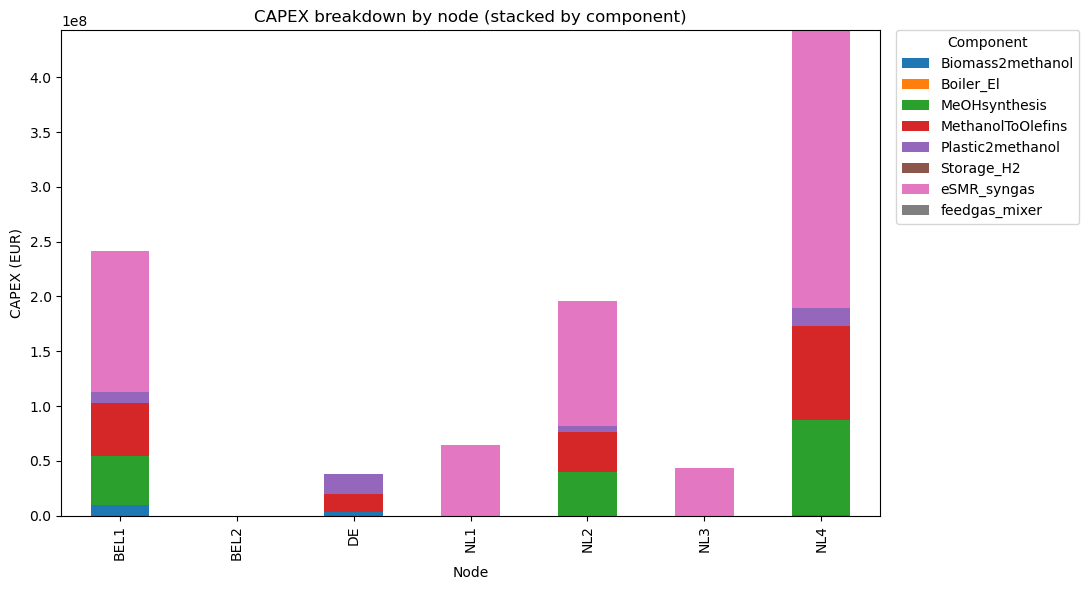

In [4]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodifica bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        if isinstance(v, (bytes, bytearray)):
            return v.decode("utf-8")
        return v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        if isinstance(v, (bytes, bytearray)):
            return v.decode("utf-8")
        return v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        if isinstance(v, (bytes, bytearray)):
            return v.decode("utf-8")
        return v
    return x

def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """
    Returns all (node, component) pairs under design/nodes/{year}.
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g_year = f[base]
        for node in g_year.keys():
            g_node = g_year[node]
            for comp in g_node.keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)

def load_technologies_design_results(dataset_name: str,
                        h5_path: str | Path,
                        year: str = "2022",
                        base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Add a column with dataset_name values to the base DataFrame created by create_base_df,
    by reading design/nodes/{year}/{node}/{component}/{dataset_name}.
    """
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan

    base = f"design/nodes/{year}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g_year = f[base]
        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]
            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan

    return df

def load_networks_design_results(dataset_name: str,
                        h5_path: str | Path,
                        year: str = "2022",
                        base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Similar to load_technologies_design_results but for design/networks/{year}/... and dataset_name like "capex".
    It will look for design/networks/{year}/{network}/{edge_id}/{dataset_name} and also try to get fromNode/toNode if they exist.
    The resulting DataFrame will have columns: node (fromNode), component (toNode), dataset_name.
    """

    h5_path = Path(h5_path)
    base = f"design/networks/{year}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g_year = f[base]

        rows = []
        for network in g_year.keys():
            g_network_path = f"{base}/{network}"
            g_network = f[g_network_path]
            for edge_id in g_network.keys():
                edge_path = f"{g_network_path}/{edge_id}"
                if edge_path in f:
                    from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                    to_node = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                    val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                    val = float(val)/2 if val is not None else np.nan  # divide by 2 to split capex between from/to
                    rows.append({"node": str(from_node), "component": str(network), dataset_name: val if val is not None else np.nan})
                    rows.append({"node": str(to_node), "component": str(network), dataset_name: val if val is not None else np.nan})

    df = pd.DataFrame(rows)

    # For the same node/component pair, if there are multiple entries (e.g. multiple edges from the same node in the same network), we sum them up.
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()

    return df

def merge_tech_and_ntw(tech_df: pd.DataFrame, ntw_df: pd.DataFrame, dataset_name: tuple[str, str], column_name: str) -> pd.DataFrame:
    """
    Combines the two dfs
    """
    # rename dataset columns to a common name for merging
    # if in df there is a column with one of the dataset_name values, rename it to column_name
    for col_name in dataset_name:
        if col_name in tech_df.columns:
            tech_df = tech_df.rename(columns={col_name: column_name})
        if col_name in ntw_df.columns:
            ntw_df = ntw_df.rename(columns={col_name: column_name})

    # merge the two dfs together on node/component, keeping all rows (outer join) and filling missing values with 0
    merged_df = pd.concat([tech_df[['node', 'component', column_name]], 
                           ntw_df[['node', 'component', column_name]]], 
                           ignore_index=True)
    merged_df[column_name] = pd.to_numeric(merged_df[column_name], errors="coerce").fillna(0.0)

    return merged_df

def plot_stacked_capex_by_node(df: pd.DataFrame,
                              capex_col: str = "capex_tot",
                              node_order: list[str] | None = None,
                              top_n_components: int | None = None,
                              drop_zeros: bool = True):
    """
    Stacked columns: x=node, stack=component, y=capex.
    - top_n_components: if we want to reduce clutter, keep the top N components (by total) and put the rest in 'Other'.
    """
    d = df.copy()
    d[capex_col] = pd.to_numeric(d[capex_col], errors="coerce").fillna(0.0)

    if drop_zeros:
        d = d[d[capex_col] > 0]

    # pivot: rows=node, columns=component
    pivot = d.pivot_table(index="node", columns="component", values=capex_col, aggfunc="sum", fill_value=0.0)

    # node order
    if node_order is not None:
        pivot = pivot.reindex(node_order)
    else:
        pivot = pivot.sort_index()

    # reduce components if requested
    if top_n_components is not None and top_n_components > 0 and pivot.shape[1] > top_n_components:
        totals = pivot.sum(axis=0).sort_values(ascending=False)
        keep = totals.index[:top_n_components]
        other = pivot.drop(columns=keep).sum(axis=1)
        pivot = pivot[keep].copy()
        pivot["Other"] = other

    # plot
    ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 6))
    ax.set_ylabel("CAPEX (EUR)")
    ax.set_xlabel("Node")
    ax.set_title("CAPEX breakdown by node (stacked by component)")
    ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

    plt.tight_layout()
    plt.show()

# Main
h5_path = r"output\backbone_20260317160512-1\optimization_results.h5"
year = "2022"

base = create_base_df(h5_path, year=year)
base_tech = load_technologies_design_results("capex_tot", h5_path, year=year, base_df=base)
base_ntw = load_networks_design_results("capex", h5_path, year=year, base_df=base)

base_combined = merge_tech_and_ntw(base_tech, base_ntw, dataset_name=("capex_tot", "capex"), column_name="capex")

# In case we want to load size as well (not needed for the plot but maybe useful for other analyses):
# base = load_design_results("size", h5_path, year=year, base_df=base)

# Node order (optional, can be customized or set to None for default sorting)
node_order = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

plot_stacked_capex_by_node(
    base_combined,
    capex_col="capex",
    node_order=node_order,
    top_n_components=None,   # set to something like 10 if the legend explodes
    drop_zeros=True
)


**Pipeline operation map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **operation** variable

In [9]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"operation/networks/{year}/{network}/{eid}/flow"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row['flow'] = (_to_scalar(f[p_val][()])).sum() if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\backbone_20260312154653-1\optimization_results.h5"
nodes_csv = r"case_studies\backbone\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="hydrogenPipelineOnshore")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="flow",
    title="Hydrogen pipeline flow"
)
plt.show()


KeyError: 'fromNode'

**Carriers input**

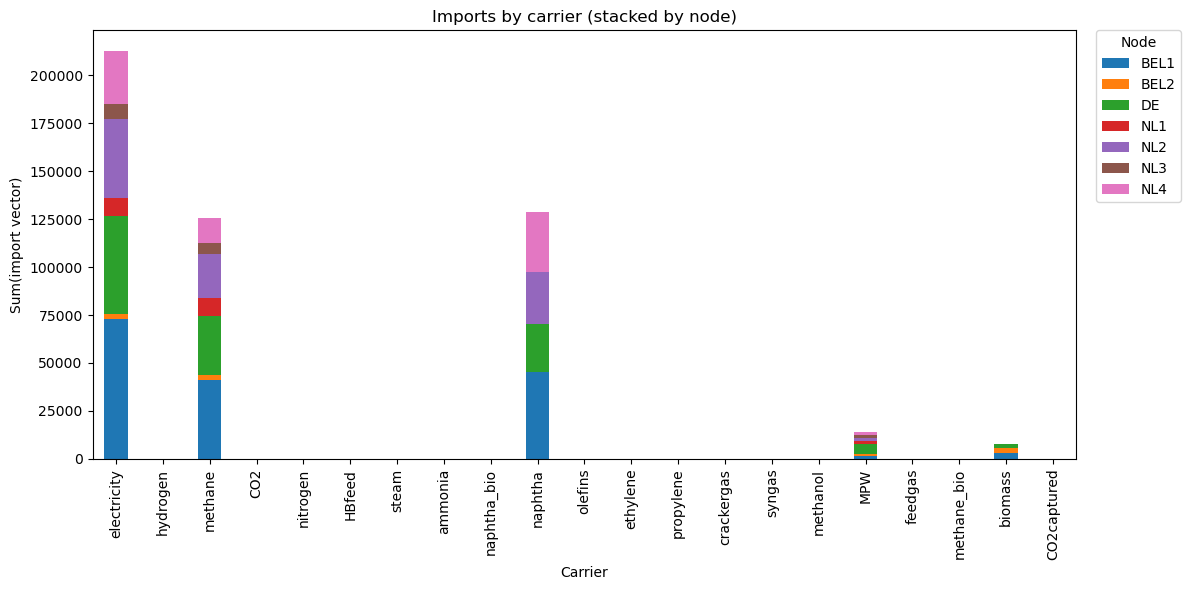

In [3]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

def _safe_sum_dataset(ds) -> float:
    """Somma robusta del dataset (vector/array), tornando float."""
    a = np.asarray(ds[()])
    if a.size == 0:
        return 0.0
    return float(np.nansum(a.astype(float)))

def _read_nodes(nodes_csv: str | Path) -> list[str]:
    nodes = pd.read_csv(nodes_csv)
    if "cluster" not in nodes.columns:
        raise KeyError(f"No 'cluster' column found in {nodes_csv}. Found columns: {nodes.columns.tolist()}")
    return nodes["cluster"].astype(str).tolist()

def _read_carriers(carriers_xlsx: str | Path, sheet_name: str = "carriers") -> list[str]:
    df = pd.read_excel(carriers_xlsx, sheet_name=sheet_name)

    # Try to find a column that looks like "carrier" or "name" (case-insensitive), otherwise take the first column
    candidates = [c for c in ["carrier", "carriers", "name", "Carrier", "Name"] if c in df.columns]
    col = candidates[0] if candidates else df.columns[0]  # fallback: prima colonna

    carriers = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .tolist()
    )
    return carriers

def read_imports_by_node_and_carrier(
    h5_path: str | Path,
    year: str,
    nodes: list[str],
    carriers: list[str],
    dataset_name: str = "import",
    base: str = "operation/energy_balance",
    missing_as_zero: bool = True,
) -> pd.DataFrame:
    """
    Read: /operation/energy_balance/{year}/{node}/{carrier}/import
    and sum vectors.
    """
    h5_path = Path(h5_path)

    rows = []
    with h5py.File(h5_path, "r") as f:
        for node in nodes:
            for car in carriers:
                ds_path = f"{base}/{year}/{node}/{car}/{dataset_name}"
                if ds_path in f:
                    total = _safe_sum_dataset(f[ds_path])
                else:
                    if missing_as_zero:
                        total = 0.0
                    else:
                        continue
                rows.append({"node": node, "carrier": car, "import_sum": total})

    return pd.DataFrame(rows)

def plot_stacked_imports(df: pd.DataFrame, node_order: list[str] | None = None, carrier_order: list[str] | None = None):
    """
    Colonne = carrier, stack = node.
    """
    d = df.copy()
    d["import_sum"] = pd.to_numeric(d["import_sum"], errors="coerce").fillna(0.0)

    pivot = d.pivot_table(index="carrier", columns="node", values="import_sum", aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        pivot = pivot.reindex(columns=node_order)
    if carrier_order is not None:
        pivot = pivot.reindex(index=carrier_order)

    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_xlabel("Carrier")
    ax.set_ylabel("Sum(import vector)")  # volutamente neutro (unità diverse)
    ax.set_title("Imports by carrier (stacked by node)")
    ax.legend(title="Node", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

# Main
case_study = "backbone"
nodes_csv = Path("case_studies") / case_study / "plants_clusters_summary.csv"
carriers_xlsx = Path("case_studies") / case_study / "carriers_list.xlsx"

# h5 dei risultati
h5_path = r"output\backbone_20260317150010-1\optimization_results.h5"
year = "2022"

nodes = _read_nodes(nodes_csv)
carriers = _read_carriers(carriers_xlsx, sheet_name="carriers")

imports_df = read_imports_by_node_and_carrier(h5_path, year, nodes, carriers)

# (opzionale) ordine nodi/carrier
node_order = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]  # se vuoi
plot_stacked_imports(imports_df, node_order=node_order, carrier_order=carriers)


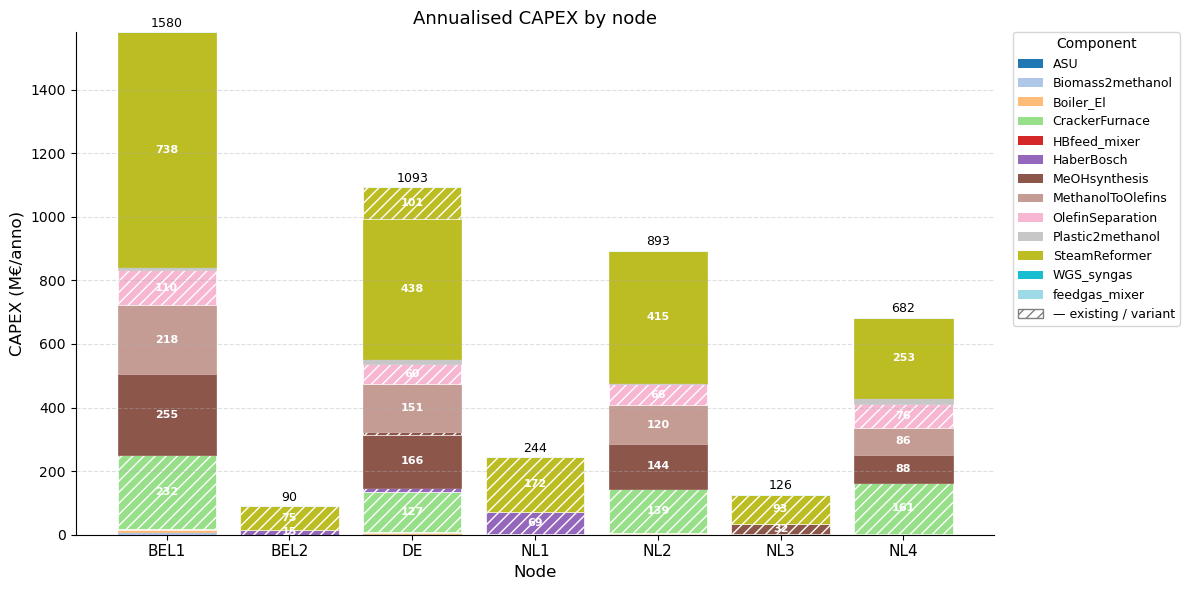

In [ ]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


# ─────────────────────────────────────────────
#  HDF5 helpers
# ─────────────────────────────────────────────

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """Returns all (node, component) pairs under design/nodes/{year}."""
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)


def load_technologies_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Adds a column with dataset_name values to base_df."""
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan
    base = f"design/nodes/{year}"
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                ds_path = f"{base}/{node}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan
    return df


def load_networks_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """Reads design/networks/{year}/... and splits capex 50/50 between fromNode and toNode."""
    h5_path = Path(h5_path)
    base = f"design/networks/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for network in f[base].keys():
            for edge_id in f[base][network].keys():
                edge_path = f"{base}/{network}/{edge_id}"
                from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                to_node   = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                val = float(val) / 2 if val is not None else np.nan
                rows.append({"node": str(from_node), "component": str(network), dataset_name: val})
                rows.append({"node": str(to_node),   "component": str(network), dataset_name: val})

    df = pd.DataFrame(rows)
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()
    return df


def merge_tech_and_ntw(
    tech_df: pd.DataFrame,
    ntw_df: pd.DataFrame,
    dataset_name: tuple[str, str],
    column_name: str,
) -> pd.DataFrame:
    """Combines technology and network DataFrames into a single one."""
    for src in (tech_df, ntw_df):
        for col in dataset_name:
            if col in src.columns:
                src.rename(columns={col: column_name}, inplace=True)

    merged = pd.concat(
        [tech_df[["node", "component", column_name]],
         ntw_df[["node", "component", column_name]]],
        ignore_index=True,
    )
    merged[column_name] = pd.to_numeric(merged[column_name], errors="coerce").fillna(0.0)
    return merged


# ─────────────────────────────────────────────
#  Technology JSON loader
# ─────────────────────────────────────────────

_TEC_SUBFOLDERS = [
    "CCSTechnologies",
    "DAC",
    "HeatGeneration",
    "HydrogenTechnologies",
    "Industrial",
    "Storage",
]

# Suffixes that appear in HDF5 component names but NOT in JSON filenames.
_KNOWN_SUFFIXES = ["_existing", "_new", "_retrofit", "_ccs"]


def _strip_suffix(name: str) -> str:
    """Strips the first matching known suffix to recover the base technology name."""
    for suffix in _KNOWN_SUFFIXES:
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def _has_suffix(name: str) -> bool:
    """Returns True if the component name carries a known suffix."""
    return any(name.endswith(s) for s in _KNOWN_SUFFIXES)


def load_tec_economics(tec_data_root: str | Path) -> pd.DataFrame:
    """
    Searches all known subfolders of tec_data_root for JSON files and reads
    the Economics section of each one.

    Returns a DataFrame with columns:
        tec_name, unit_capex, fix_capex, lifetime, discount_rate, crf
    """
    tec_data_root = Path(tec_data_root)
    rows = []

    for subfolder in _TEC_SUBFOLDERS:
        folder = tec_data_root / subfolder
        if not folder.exists():
            continue
        for json_file in folder.glob("*.json"):
            try:
                with open(json_file, encoding="utf-8") as fh:
                    data = json.load(fh)
                econ       = data.get("Economics", {})
                r          = econ.get("discount_rate")
                n          = econ.get("lifetime")
                unit_capex = econ.get("unit_capex")
                fix_capex  = econ.get("fix_capex", 0.0)

                if r is None or n is None or unit_capex is None:
                    continue

                r, n       = float(r), float(n)
                unit_capex = float(unit_capex)
                fix_capex  = float(fix_capex) if fix_capex is not None else 0.0
                crf        = (r * (1 + r) ** n) / ((1 + r) ** n - 1) if n > 0 else 1.0

                rows.append({
                    "tec_name":      json_file.stem,
                    "unit_capex":    unit_capex,
                    "fix_capex":     fix_capex,
                    "lifetime":      n,
                    "discount_rate": r,
                    "crf":           crf,
                })
            except Exception as e:
                print(f"Warning: could not parse {json_file.name}: {e}")

    df = pd.DataFrame(rows)
    if df.empty:
        print(
            f"Warning: no JSON files with Economics data found under '{tec_data_root}'. "
            f"Searched subfolders: {_TEC_SUBFOLDERS}"
        )
    return df


# ─────────────────────────────────────────────
#  Capex recomputation from size × unit_capex
# ─────────────────────────────────────────────

def compute_capex_from_size(
    df: pd.DataFrame,
    tec_economics: pd.DataFrame,
    size_col: str = "size",
    capex_col: str = "capex_recomputed",
    annualized_col: str = "capex_annualized",
    warn_missing: bool = True,
) -> pd.DataFrame:
    """
    Recomputes capex for every (node, component) row using:

        capex            = size * unit_capex + fix_capex
        capex_annualized = capex * CRF

    '_existing' / '_new' suffixes are stripped to find the matching JSON,
    but the original component name is preserved in the DataFrame.
    """
    df = df.copy()

    lookup = {row["tec_name"]: row for _, row in tec_economics.iterrows()}

    def _match(comp: str):
        if comp in lookup:
            return lookup[comp]
        base = _strip_suffix(comp)
        if base in lookup:
            return lookup[base]
        return None

    capex_vals, annualized_vals = [], []

    for _, row in df.iterrows():
        econ = _match(row["component"])
        size = pd.to_numeric(row.get(size_col), errors="coerce")

        if econ is None or pd.isna(size):
            capex_vals.append(np.nan)
            annualized_vals.append(np.nan)
        else:
            capex = size * econ["unit_capex"] + econ["fix_capex"]
            capex_vals.append(capex)
            annualized_vals.append(capex * econ["crf"])

    df[capex_col]      = capex_vals
    df[annualized_col] = annualized_vals

    if warn_missing:
        missing = df.loc[
            df[capex_col].isna()
            & pd.to_numeric(df.get(size_col, np.nan), errors="coerce").notna(),
            "component",
        ].unique()
        if len(missing):
            print(
                f"Warning: no JSON found for {len(missing)} component(s) — "
                f"capex will be NaN for: {sorted(missing)}"
            )

    return df


# ─────────────────────────────────────────────
#  Color + hatch palette
# ─────────────────────────────────────────────

# Hatch pattern used for all "variant" components (existing, new, …)
_HATCH_PATTERN = "///"


def _build_palette(
    components: list[str],
    cmap_name: str = "tab20",
) -> tuple[dict[str, str], dict[str, str]]:
    """
    Builds two dicts keyed on component name:
      - color_map : hex color  (same for base and its variants)
      - hatch_map : hatch string ('' for base, '///' for variants)

    Colors are assigned to *base* names (suffix stripped); variant components
    inherit the same color as their base.
    """
    # Collect unique base names, preserving the order of first appearance
    seen: dict[str, None] = {}
    for comp in components:
        seen[_strip_suffix(comp)] = None
    base_names = list(seen.keys())

    n = len(base_names)
    if n <= 20:
        cmap   = plt.get_cmap(cmap_name)
        colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]
    else:
        cmap   = plt.get_cmap("hsv")
        colors = [mcolors.to_hex(cmap(i / n)) for i in range(n)]

    base_color = dict(zip(base_names, colors))

    color_map = {comp: base_color[_strip_suffix(comp)] for comp in components}
    hatch_map = {comp: (_HATCH_PATTERN if _has_suffix(comp) else "") for comp in components}

    return color_map, hatch_map


# ─────────────────────────────────────────────
#  Plot
# ─────────────────────────────────────────────

def plot_stacked_capex_by_node(
    df: pd.DataFrame,
    capex_col: str = "capex_annualized",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "CAPEX breakdown by node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart: x=node, stack=component, y=capex.

    Components with a known suffix (_existing, _new, …) are drawn with the
    same color as their base technology but with diagonal hatch stripes.

    Parameters
    ----------
    df                 : DataFrame with columns node, component, capex_col
    capex_col          : column to plot
    node_order         : custom x-axis order; None = alphabetical
    top_n_components   : keep only the top-N base technologies by total;
                         group the rest as 'Other' (variants are counted with their base)
    drop_zeros         : remove rows where value == 0
    scale              : divide values by this factor (default 1e6 -> millions)
    scale_label        : unit label on y-axis
    cmap_name          : matplotlib colormap for automatic color assignment
    title              : chart title
    figsize            : figure size in inches
    min_fraction_label : min fraction of node total to print a value label inside a bar slice
    """
    d = df.copy()
    d[capex_col] = pd.to_numeric(d[capex_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[capex_col] > 0]

    d[capex_col] = d[capex_col] / scale

    pivot = d.pivot_table(
        index="node", columns="component",
        values=capex_col, aggfunc="sum", fill_value=0.0,
    )

    # Node order
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        extra = [n for n in pivot.index if n not in valid]
        pivot = pivot.reindex(valid + extra)
    else:
        pivot = pivot.sort_index()

    # Optionally collapse minor technologies into 'Other'
    # (group by base name so a base + its variants count together)
    if top_n_components is not None and len({_strip_suffix(c) for c in pivot.columns}) > top_n_components:
        base_totals = (
            pivot.rename(columns=_strip_suffix)
            .T.groupby(level=0).sum().T
            .sum(axis=0)
            .sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components        = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name=cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    x       = np.arange(len(pivot.index))
    bottoms = np.zeros(len(pivot.index))

    for comp in components:
        values = pivot[comp].values
        bars   = ax.bar(
            x, values, bottom=bottoms,
            color=color_map[comp],
            hatch=hatch_map[comp],
            edgecolor="white" if hatch_map[comp] else color_map[comp],
            linewidth=0.5,
            label=comp,
        )

        node_totals = pivot.sum(axis=1).values
        for i, (bar, v) in enumerate(zip(bars, values)):
            if node_totals[i] > 0 and v / node_totals[i] >= min_fraction_label:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f"{v:.0f}",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )
        bottoms += values

    # Total on top of each bar
    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            x[i], total + 0.01 * (pivot.values.max() or 1),
            f"{total:.0f}",
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
    ax.set_ylabel(f"CAPEX ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    # ── Custom legend ──
    # One solid patch per base technology + one hatched example patch
    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(
                mpatches.Patch(facecolor=color_map[comp], label=base)
            )

    # Add a single "existing / variant" indicator if any hatched component exists
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(
                facecolor="white", edgecolor="gray",
                hatch=_HATCH_PATTERN, label="— existing / variant",
            )
        )

    ax.legend(
        handles=legend_handles,
        title="Component",
        bbox_to_anchor=(1.02, 1), loc="upper left",
        borderaxespad=0, fontsize=9,
    )

    plt.tight_layout()
    # plt.savefig("capex_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path       = Path(r"output\backbone_20260319094645-1\optimization_results.h5")
    tec_data_root = Path(r"adopt_net0\database\templates\technology_data")
    year          = "2022"

    base     = create_base_df(h5_path, year=year)
    tech_df  = load_technologies_design_results("size", h5_path, year=year, base_df=base)
    ntw_df   = load_networks_design_results("capex", h5_path, year=year)
    tec_econ = load_tec_economics(tec_data_root)

    tech_df = compute_capex_from_size(
        tech_df,
        tec_economics=tec_econ,
        size_col="size",
        capex_col="capex_recomputed",
        annualized_col="capex_annualized",
    )

    ntw_df = ntw_df.rename(columns={"capex": "capex_recomputed"})
    ntw_df["capex_annualized"] = np.nan

    combined = pd.concat(
        [tech_df[["node", "component", "capex_recomputed", "capex_annualized"]],
         ntw_df[["node", "component", "capex_recomputed", "capex_annualized"]]],
        ignore_index=True,
    )

    node_order = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

    plot_stacked_capex_by_node(
        combined.dropna(subset=["capex_annualized"]),
        capex_col="capex_annualized",
        node_order=node_order,
        title="Annualised CAPEX by node",
        scale=1e6,
        scale_label="M€/year",
    )

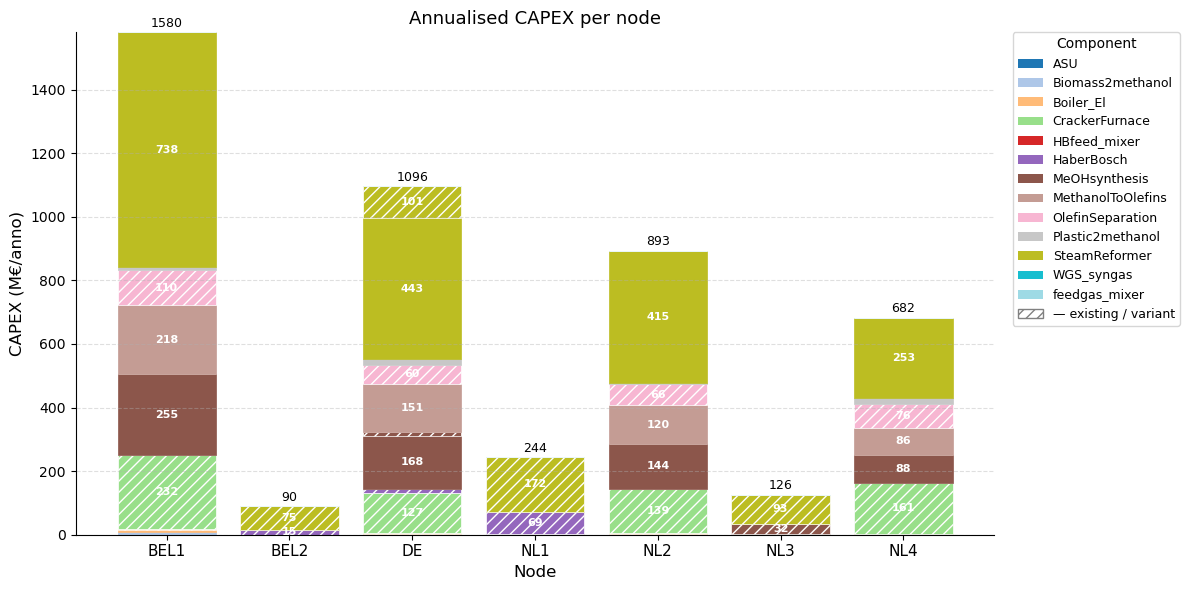

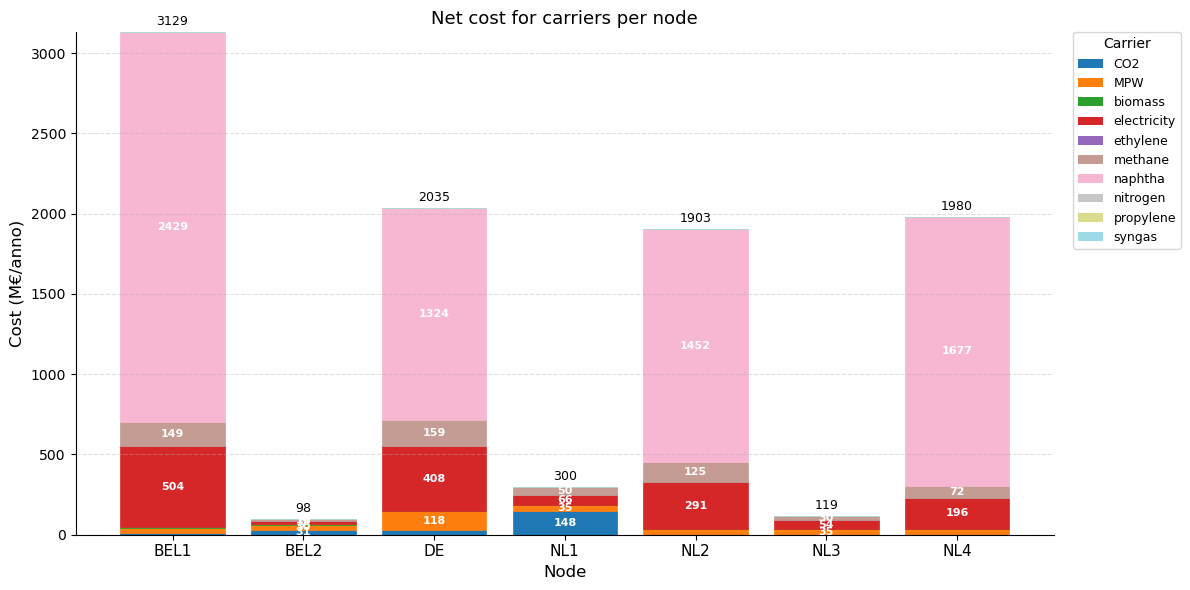

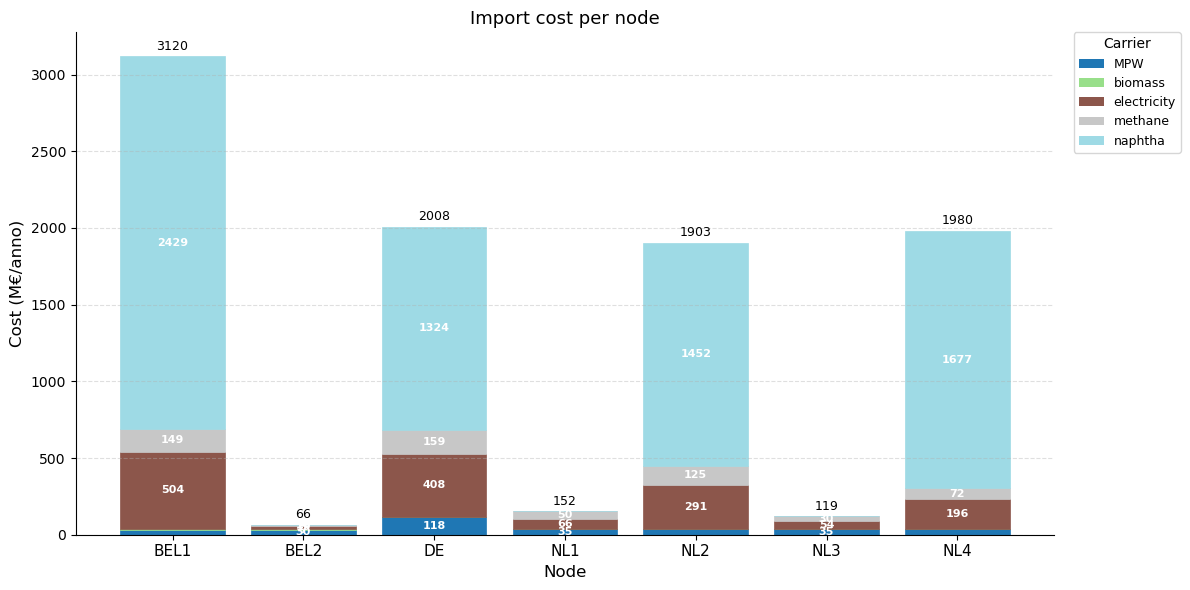

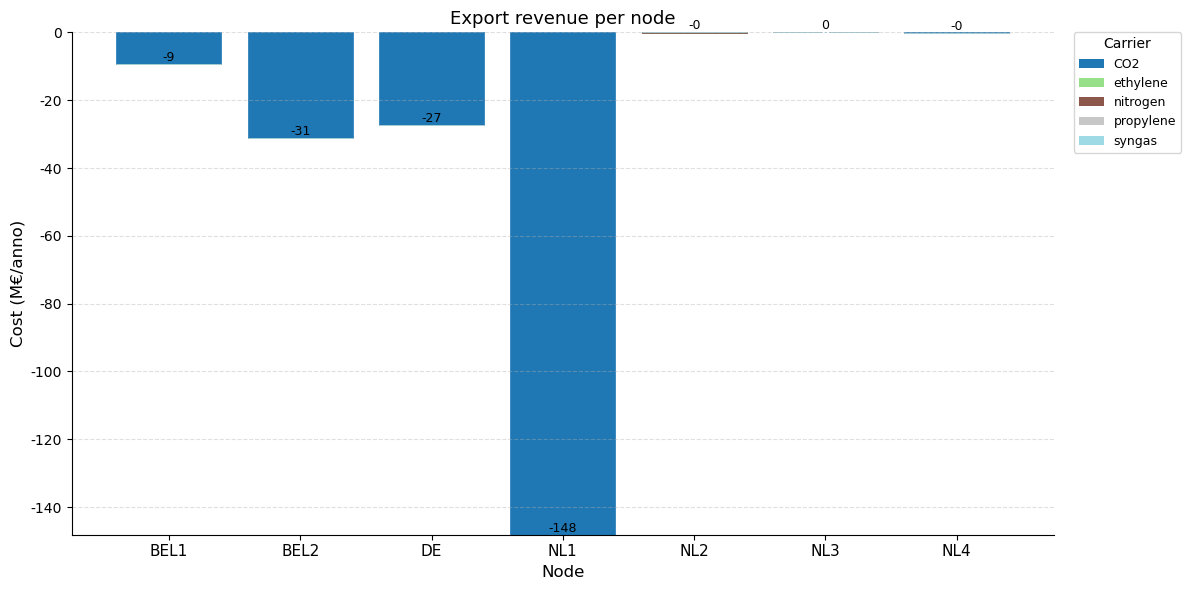

In [ ]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


# ─────────────────────────────────────────────
#  HDF5 helpers
# ─────────────────────────────────────────────

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """Returns all (node, component) pairs under design/nodes/{year}."""
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)


def load_technologies_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Adds a column with dataset_name values to base_df."""
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan
    base = f"design/nodes/{year}"
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                ds_path = f"{base}/{node}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan
    return df


def load_networks_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """Reads design/networks/{year}/... and splits capex 50/50 between fromNode and toNode."""
    h5_path = Path(h5_path)
    base = f"design/networks/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for network in f[base].keys():
            for edge_id in f[base][network].keys():
                edge_path = f"{base}/{network}/{edge_id}"
                from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                to_node   = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                val = float(val) / 2 if val is not None else np.nan
                rows.append({"node": str(from_node), "component": str(network), dataset_name: val})
                rows.append({"node": str(to_node),   "component": str(network), dataset_name: val})

    df = pd.DataFrame(rows)
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()
    return df


def merge_tech_and_ntw(
    tech_df: pd.DataFrame,
    ntw_df: pd.DataFrame,
    dataset_name: tuple[str, str],
    column_name: str,
) -> pd.DataFrame:
    """Combines technology and network DataFrames into a single one."""
    for src in (tech_df, ntw_df):
        for col in dataset_name:
            if col in src.columns:
                src.rename(columns={col: column_name}, inplace=True)

    merged = pd.concat(
        [tech_df[["node", "component", column_name]],
         ntw_df[["node", "component", column_name]]],
        ignore_index=True,
    )
    merged[column_name] = pd.to_numeric(merged[column_name], errors="coerce").fillna(0.0)
    return merged


# ─────────────────────────────────────────────
#  Technology JSON loader
# ─────────────────────────────────────────────

_TEC_SUBFOLDERS = [
    "CCSTechnologies",
    "DAC",
    "HeatGeneration",
    "HydrogenTechnologies",
    "Industrial",
    "Storage",
]

_KNOWN_SUFFIXES = ["_existing", "_new", "_ccs"]


def _strip_suffix(name: str) -> str:
    """Strips the first matching known suffix to recover the base technology name."""
    for suffix in _KNOWN_SUFFIXES:
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def _has_suffix(name: str) -> bool:
    return any(name.endswith(s) for s in _KNOWN_SUFFIXES)


# def load_tec_economics(tec_data_root: str | Path) -> pd.DataFrame:
#     """
#     Searches all known subfolders of tec_data_root for JSON files and reads
#     the Economics section. Returns a DataFrame with columns:
#         tec_name, unit_capex, fix_capex, lifetime, discount_rate, crf
#     """
#     tec_data_root = Path(tec_data_root)
#     rows = []
#     for subfolder in _TEC_SUBFOLDERS:
#         folder = tec_data_root / subfolder
#         if not folder.exists():
#             continue
#         for json_file in folder.glob("*.json"):
#             try:
#                 with open(json_file, encoding="utf-8") as fh:
#                     data = json.load(fh)
#                 econ       = data.get("Economics", {})
#                 r          = econ.get("discount_rate")
#                 n          = econ.get("lifetime")
#                 unit_capex = econ.get("unit_capex")
#                 fix_capex  = econ.get("fix_capex", 0.0)
#                 if r is None or n is None or unit_capex is None:
#                     continue
#                 r, n       = float(r), float(n)
#                 unit_capex = float(unit_capex)
#                 fix_capex  = float(fix_capex) if fix_capex is not None else 0.0
#                 crf        = (r * (1 + r) ** n) / ((1 + r) ** n - 1) if n > 0 else 1.0
#                 rows.append({"tec_name": json_file.stem, "unit_capex": unit_capex,
#                              "fix_capex": fix_capex, "lifetime": n,
#                              "discount_rate": r, "crf": crf})
#             except Exception as e:
#                 print(f"Warning: could not parse {json_file.name}: {e}")

#     df = pd.DataFrame(rows)
#     if df.empty:
#         print(f"Warning: no JSON files found under '{tec_data_root}'. Searched: {_TEC_SUBFOLDERS}")
#     return df


def compute_capex_from_size(
    df: pd.DataFrame,
    tec_economics: pd.DataFrame,
    size_col: str = "size",
    capex_col: str = "capex_recomputed",
    annualized_col: str = "capex_annualized",
    warn_missing: bool = True,
) -> pd.DataFrame:
    """
    capex            = size * unit_capex + fix_capex
    capex_annualized = capex * CRF
    Suffixes (_existing, _new, …) are stripped to find the matching JSON.
    """
    df = df.copy()
    lookup = {row["tec_name"]: row for _, row in tec_economics.iterrows()}

    def _match(comp):
        if comp in lookup:
            return lookup[comp]
        base = _strip_suffix(comp)
        return lookup.get(base)

    capex_vals, annualized_vals = [], []
    for _, row in df.iterrows():
        econ = _match(row["component"])
        size = pd.to_numeric(row.get(size_col), errors="coerce")
        if econ is None or pd.isna(size):
            capex_vals.append(np.nan)
            annualized_vals.append(np.nan)
        else:
            capex = size * econ["unit_capex"] + econ["fix_capex"]
            capex_vals.append(capex)
            annualized_vals.append(capex * econ["crf"])

    df[capex_col]      = capex_vals
    df[annualized_col] = annualized_vals

    if warn_missing:
        missing = df.loc[
            df[capex_col].isna()
            & pd.to_numeric(df.get(size_col, np.nan), errors="coerce").notna(),
            "component",
        ].unique()
        if len(missing):
            print(f"Warning: no JSON found for {len(missing)} component(s): {sorted(missing)}")
    return df


# ─────────────────────────────────────────────
#  Import / Export cost loader
# ─────────────────────────────────────────────

def load_import_export_costs(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, carrier) pair computes the annual import and export costs
    using the k-means weighting factors stored in k_means_specs/{year}/factors.

    Annual cost formula (weighted sum over typical-day timesteps):
        import_cost  = sum_t( import[t]  * import_price[t]  * factor[t] )
        export_cost  = sum_t( export[t]  * export_price[t]  * factor[t] )
        net_cost     = import_cost - export_cost   (positive = net spend)

    The factors already sum to 8760, so the result is in [EUR] per year
    (assuming flows are in [unit/h] and prices in [EUR/unit]).

    Returns a DataFrame with columns:
        node, carrier, import_cost, export_cost, net_cost
    """
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as f:
        # Load k-means factors (shape: n_timesteps)
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)

        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")

        for node in f[eb_base].keys():
            for carrier in f[eb_base][node].keys():
                carrier_path = f"{eb_base}/{node}/{carrier}"

                imp       = np.array(f[f"{carrier_path}/import"],       dtype=float)
                exp       = np.array(f[f"{carrier_path}/export"],       dtype=float)
                imp_price = np.array(f[f"{carrier_path}/import_price"], dtype=float)
                exp_price = np.array(f[f"{carrier_path}/export_price"], dtype=float)

                import_cost = float(np.sum(imp * imp_price * factors))
                export_cost = float(np.sum(exp * exp_price * factors))

                rows.append({
                    "node":        str(node),
                    "carrier":     str(carrier),
                    "import_cost": import_cost,
                    "export_cost": export_cost,
                    "net_cost":    import_cost - export_cost,
                })

    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
#  Color + hatch palette
# ─────────────────────────────────────────────

_HATCH_PATTERN = "///"


def _build_palette(
    components: list[str],
    cmap_name: str = "tab20",
) -> tuple[dict[str, str], dict[str, str]]:
    """
    Returns (color_map, hatch_map) keyed on component name.
    Colors are assigned to base names; variants (with known suffix) share
    the same color but get a hatch pattern.
    """
    seen: dict[str, None] = {}
    for comp in components:
        seen[_strip_suffix(comp)] = None
    base_names = list(seen.keys())

    n = len(base_names)
    if n <= 20:
        cmap   = plt.get_cmap(cmap_name)
        colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]
    else:
        cmap   = plt.get_cmap("hsv")
        colors = [mcolors.to_hex(cmap(i / n)) for i in range(n)]

    base_color = dict(zip(base_names, colors))
    color_map  = {comp: base_color[_strip_suffix(comp)] for comp in components}
    hatch_map  = {comp: (_HATCH_PATTERN if _has_suffix(comp) else "") for comp in components}
    return color_map, hatch_map


def _build_simple_palette(
    items: list[str],
    cmap_name: str = "tab20",
) -> dict[str, str]:
    """Simple color palette (no hatch logic) for carriers or other flat lists."""
    n = len(items)
    if n <= 20:
        cmap   = plt.get_cmap(cmap_name)
        colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]
    else:
        cmap   = plt.get_cmap("hsv")
        colors = [mcolors.to_hex(cmap(i / n)) for i in range(n)]
    return dict(zip(items, colors))


# ─────────────────────────────────────────────
#  Generic stacked bar plot
# ─────────────────────────────────────────────

def _plot_stacked(
    pivot: pd.DataFrame,
    color_map: dict[str, str],
    hatch_map: dict[str, str] | None,
    ax: plt.Axes,
    scale: float,
    min_fraction_label: float,
):
    """Core drawing routine shared by both plot functions."""
    hatch_map = hatch_map or {c: "" for c in pivot.columns}
    x       = np.arange(len(pivot.index))
    bottoms = np.zeros(len(pivot.index))

    for comp in pivot.columns:
        values = pivot[comp].values
        bars   = ax.bar(
            x, values, bottom=bottoms,
            color=color_map[comp],
            hatch=hatch_map[comp],
            edgecolor="white" if hatch_map[comp] else color_map[comp],
            linewidth=0.5,
            label=comp,
        )
        node_totals = pivot.sum(axis=1).values
        for i, (bar, v) in enumerate(zip(bars, values)):
            if node_totals[i] > 0 and v / node_totals[i] >= min_fraction_label:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f"{v:.0f}",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )
        bottoms += values

    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            x[i], total + 0.01 * (pivot.values.max() or 1),
            f"{total:.0f}",
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)


# ─────────────────────────────────────────────
#  Plot: CAPEX annualizzato
# ─────────────────────────────────────────────

def plot_stacked_capex_by_node(
    df: pd.DataFrame,
    capex_col: str = "capex_annualized",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "CAPEX breakdown by node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart of capex by node and component.
    Components with a known suffix (_existing, _new, …) share the same color
    as their base technology but are drawn with diagonal hatch stripes.
    """
    d = df.copy()
    d[capex_col] = pd.to_numeric(d[capex_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[capex_col] > 0]
    d[capex_col] /= scale

    pivot = d.pivot_table(index="node", columns="component",
                          values=capex_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T.sum(axis=0)
            .sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components        = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, scale, min_fraction_label)

    ax.set_ylabel(f"CAPEX ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    plt.savefig("capex_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Plot: costi import/export per carrier
# ─────────────────────────────────────────────

def plot_stacked_import_export_by_node(
    df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Import/export costs by node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart of import/export costs by node and carrier.

    Parameters
    ----------
    df            : output of load_import_export_costs()
    cost_col      : which cost column to plot:
                    'import_cost'  — only import spending
                    'export_cost'  — only export revenue
                    'net_cost'     — import_cost - export_cost (default)
    node_order    : custom x-axis order
    top_n_carriers: keep only the top-N carriers by total cost
    drop_zeros    : remove rows where cost == 0
    scale         : divide values by this factor (default 1e6 -> millions)
    scale_label   : unit label on y-axis
    cmap_name     : matplotlib colormap
    title         : chart title
    figsize       : figure size in inches
    min_fraction_label : min fraction of node total to print a value label
    """
    d = df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="carrier",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals    = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep      = totals.index[:top_n_carriers].tolist()
        other     = pivot.drop(columns=keep).sum(axis=1)
        pivot     = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other

    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}   # no hatch for carriers

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, scale=1.0,  # already scaled
                  min_fraction_label=min_fraction_label)

    ax.set_ylabel(f"Cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    plt.savefig("import_export_costs.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path       = Path(r"output\backbone_20260319110812-1\optimization_results.h5")
    tec_data_root = Path(r"adopt_net0\database\templates\technology_data")
    year          = "2022"
    node_order    = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

    # ── CAPEX annualizzato ───────────────────
    base     = create_base_df(h5_path, year=year)
    tech_df  = load_technologies_design_results("size", h5_path, year=year, base_df=base)
    ntw_df   = load_networks_design_results("capex", h5_path, year=year)
    tec_econ = load_tec_economics(tec_data_root)

    tech_df = compute_capex_from_size(
        tech_df, tec_econ,
        size_col="size", capex_col="capex_recomputed", annualized_col="capex_annualized",
    )
    ntw_df = ntw_df.rename(columns={"capex": "capex_recomputed"})
    ntw_df["capex_annualized"] = np.nan

    combined_capex = pd.concat(
        [tech_df[["node", "component", "capex_recomputed", "capex_annualized"]],
         ntw_df[["node", "component", "capex_recomputed", "capex_annualized"]]],
        ignore_index=True,
    )

    plot_stacked_capex_by_node(
        combined_capex.dropna(subset=["capex_annualized"]),
        capex_col="capex_annualized",
        node_order=node_order,
        title="Annualised CAPEX per node",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Costi import/export ──────────────────
    ie_costs = load_import_export_costs(h5_path, year=year)

    # Net cost (import spending minus export revenue)
    plot_stacked_import_export_by_node(
        ie_costs,
        cost_col="net_cost",
        node_order=node_order,
        title="Net cost for carriers per node",
        scale=1e6, scale_label="M€/anno",
    )

    # Import only
    plot_stacked_import_export_by_node(
        ie_costs,
        cost_col="import_cost",
        node_order=node_order,
        title="Import cost per node",
        scale=1e6, scale_label="M€/anno",
    )

    # Export only
    plot_stacked_import_export_by_node(
        ie_costs,
        cost_col="export_cost",
        node_order=node_order,
        title="Export revenue per node",
        scale=1e6, scale_label="M€/anno",
    )

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_37392\1870910068.py:208: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = mcm.get_cmap(cmap_name)


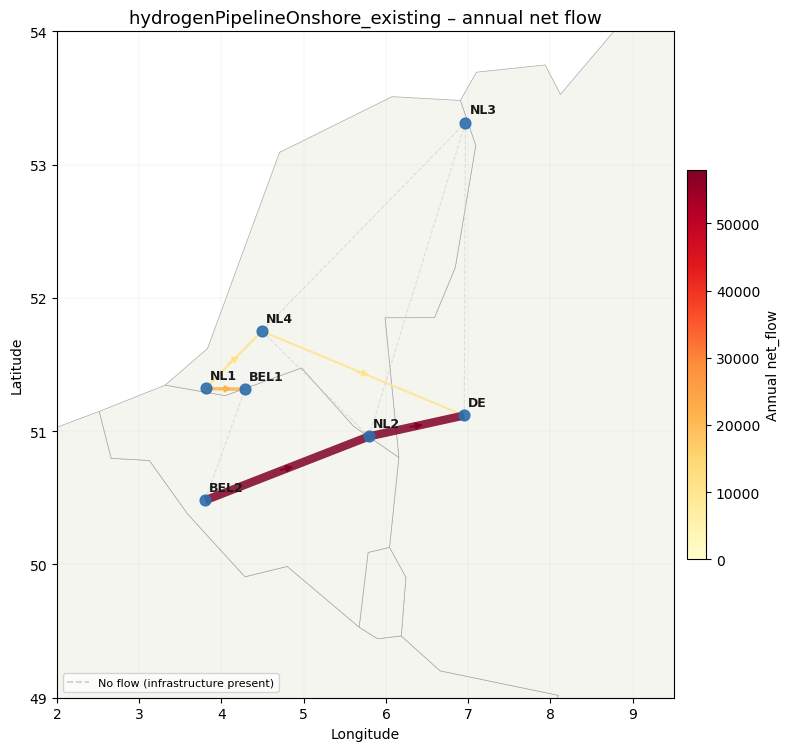

ValueError: Cannot set a DataFrame without columns to the column pair

In [2]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from matplotlib.lines import Line2D
from shapely.geometry import LineString


# ─────────────────────────────────────────────
#  HDF5 helper
# ─────────────────────────────────────────────

def _to_scalar(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


# ─────────────────────────────────────────────
#  Data loading
# ─────────────────────────────────────────────

def read_network_flows(
    h5_path: str | Path,
    year: str = "2022",
    network: str = "hydrogenPipelineOnshore_existing",
) -> pd.DataFrame:
    """
    Reads all edges of a network and computes the **annual flow** using
    k-means weighting factors:

        annual_flow(edge) = sum_t( flow[t] * factor[t] )

    For each undirected pair (A, B) the net flow and dominant direction are
    computed:
        net_flow  = annual_flow(A→B) − annual_flow(B→A)
        direction : A→B if net_flow > 0, else B→A
        |net_flow|: used for visual scaling

    Returns a DataFrame with columns:
        edge_id, fromNode, toNode,          ← original directed edge
        annual_flow,                         ← weighted annual flow (directed)
        pair, net_from, net_to, net_flow     ← undirected pair with net direction
    """
    h5_path = Path(h5_path)
    base_design = f"design/networks/{year}/{network}"
    base_op     = f"operation/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base_design not in f:
            raise KeyError(f"'{base_design}' not found in HDF5.")

        factors = np.array(f[f"k_means_specs/{year}/factors"], dtype=float)

        rows = []
        for eid in f[base_design].keys():
            from_node = _to_scalar(f[f"{base_design}/{eid}/fromNode"][()])
            to_node   = _to_scalar(f[f"{base_design}/{eid}/toNode"][()])

            flow_path = f"{base_op}/{eid}/flow"
            if flow_path in f:
                flow = np.array(f[flow_path], dtype=float)
                annual = float(np.sum(flow * factors))
            else:
                annual = 0.0

            rows.append({
                "edge_id":    eid,
                "fromNode":   str(from_node),
                "toNode":     str(to_node),
                "annual_flow": annual,
            })

    df = pd.DataFrame(rows)

    # ── Net flow per undirected pair ──────────────────────────────────────
    # canonical pair key: always sort nodes alphabetically
    df["pair"] = df.apply(
        lambda r: tuple(sorted([r["fromNode"], r["toNode"]])), axis=1
    )

    net_rows = []
    for pair, grp in df.groupby("pair"):
        a, b = pair
        flow_ab = grp.loc[grp["fromNode"] == a, "annual_flow"].sum()
        flow_ba = grp.loc[grp["fromNode"] == b, "annual_flow"].sum()
        net = flow_ab - flow_ba
        net_rows.append({
            "pair":     pair,
            "net_from": a if net >= 0 else b,
            "net_to":   b if net >= 0 else a,
            "net_flow": abs(net),
        })

    net_df = pd.DataFrame(net_rows)
    df = df.merge(net_df, on="pair", how="left")
    return df


def attach_geometry(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
) -> pd.DataFrame:
    """
    Adds from/to coordinates from a CSV with columns: cluster, latitude, longitude.
    Uses net_from / net_to so geometry already reflects the net flow direction.
    """
    nodes  = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)
    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["from_lat"] = out["net_from"].map(coords["latitude"])
    out["from_lon"] = out["net_from"].map(coords["longitude"])
    out["to_lat"]   = out["net_to"].map(coords["latitude"])
    out["to_lon"]   = out["net_to"].map(coords["longitude"])
    return out


# ─────────────────────────────────────────────
#  Map
# ─────────────────────────────────────────────

def plot_network_map(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
    flow_col: str = "net_flow",
    bbox: tuple[float, float, float, float] = (2.0, 49.0, 9.5, 54.0),
    min_lw: float = 0.5,
    max_lw: float = 6.0,
    cmap_name: str = "YlOrRd",
    node_size: int = 60,
    node_color: str = "#2c6fad",
    arrow_scale: float = 0.015,
    title: str | None = None,
    figsize: tuple[int, int] = (8, 9),
    basemap_url: str = (
        "https://naturalearth.s3.amazonaws.com/110m_cultural/"
        "ne_110m_admin_0_countries.zip"
    ),
):
    """
    Draws a geographic map of network flows.

    Visual encoding:
      - Line **width**  → proportional to net_flow magnitude
      - Line **color**  → proportional to net_flow magnitude (colormap)
      - **Arrow**       → indicates net flow direction (drawn at midpoint)
      - Zero-flow edges → drawn as thin dashed gray lines (infrastructure present
                          but unused)

    Parameters
    ----------
    edges_df    : output of attach_geometry()
    nodes_csv   : CSV with columns cluster, latitude, longitude
    flow_col    : column used for scaling (default 'net_flow')
    bbox        : (lon_min, lat_min, lon_max, lat_max) for the map extent
    min_lw      : minimum linewidth for non-zero flows
    max_lw      : maximum linewidth
    cmap_name   : matplotlib colormap for flow color
    node_size   : marker size for nodes
    node_color  : color of node markers
    arrow_scale : length of direction arrows relative to map extent
    title       : plot title
    figsize     : figure size in inches
    basemap_url : URL or local path for the basemap shapefile/zip
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326",
    ).cx[lon_min:lon_max, lat_min:lat_max]

    # ── Build undirected edge GeoDataFrame (one row per pair) ──────────────
    ed = edges_df.drop_duplicates(subset="pair").copy()
    ed[flow_col] = pd.to_numeric(ed[flow_col], errors="coerce").fillna(0.0)

    valid = ed[["from_lon", "from_lat", "to_lon", "to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()
    ed["geometry"] = ed.apply(
        lambda r: LineString(
            [(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]
        ),
        axis=1,
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # ── Color and linewidth scaling ────────────────────────────────────────
    flows    = g_edges[flow_col].to_numpy(dtype=float)
    flow_max = float(flows[flows > 0].max()) if (flows > 0).any() else 1.0

    cmap  = mcm.get_cmap(cmap_name)
    norm  = mcolors.Normalize(vmin=0, vmax=flow_max)

    def _lw(v):
        if v <= 0:
            return 0.0
        return min_lw + (max_lw - min_lw) * (v / flow_max)

    g_edges["lw"]    = g_edges[flow_col].apply(_lw)
    g_edges["color"] = g_edges[flow_col].apply(
        lambda v: cmap(norm(v)) if v > 0 else (0.7, 0.7, 0.7, 1.0)
    )

    # ── Figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # Basemap
    try:
        world = gpd.read_file(basemap_url)
        world.cx[lon_min:lon_max, lat_min:lat_max].plot(
            ax=ax, color="#f5f5f0", edgecolor="#aaaaaa", linewidth=0.5
        )
    except Exception as e:
        print(f"Warning: basemap not loaded ({e}). Continuing without.")
        ax.set_facecolor("#d6e8f5")

    # Zero-flow edges (infrastructure exists but unused)
    zero_edges = g_edges[g_edges[flow_col] == 0]
    if not zero_edges.empty:
        zero_edges.plot(
            ax=ax, linewidth=0.8, linestyle="--", color="#cccccc", alpha=0.6
        )

    # Active edges: sorted so thicker lines are drawn on top
    active_edges = g_edges[g_edges[flow_col] > 0].sort_values("lw")
    for _, row in active_edges.iterrows():
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326").plot(
            ax=ax, linewidth=row["lw"], color=row["color"], alpha=0.85
        )

    # Direction arrows at edge midpoints
    dx = (lon_max - lon_min) * arrow_scale
    dy = (lat_max - lat_min) * arrow_scale
    for _, row in active_edges.iterrows():
        coords = list(row.geometry.coords)
        mx = (coords[0][0] + coords[1][0]) / 2
        my = (coords[0][1] + coords[1][1]) / 2
        # direction vector (normalised)
        vx = coords[1][0] - coords[0][0]
        vy = coords[1][1] - coords[0][1]
        length = (vx**2 + vy**2) ** 0.5
        if length == 0:
            continue
        ax.annotate(
            "", xy=(mx + dx * vx / length, my + dy * vy / length),
            xytext=(mx - dx * vx / length, my - dy * vy / length),
            arrowprops=dict(
                arrowstyle="-|>",
                color=row["color"],
                lw=1.2,
                mutation_scale=10,
            ),
        )

    # Nodes
    g_nodes.plot(ax=ax, markersize=node_size, color=node_color, zorder=5, alpha=0.9)
    for _, r in g_nodes.iterrows():
        ax.text(
            r["longitude"] + 0.05, r["latitude"] + 0.07,
            str(r["cluster"]),
            fontsize=9, fontweight="bold", zorder=6,
            color="#1a1a1a",
        )

    # Colorbar
    sm = mcm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"Annual {flow_col}", fontsize=10)

    # Legend for zero-flow edges
    legend_elements = [
        Line2D([0], [0], color="#cccccc", lw=1.2, linestyle="--",
               label="No flow (infrastructure present)"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=8, framealpha=0.8)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.set_title(title or f"Network – {flow_col}", fontsize=13)
    ax.grid(True, linewidth=0.2, alpha=0.4)

    plt.tight_layout()
    return fig, ax


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path   = Path(r"output\backbone_20260319114307-1\optimization_results.h5")
    nodes_csv = Path(r"case_studies\backbone\plants_clusters_summary.csv")
    year      = "2022"

    for network in ["hydrogenPipelineOnshore_existing", "hydrogenPipelineOnshore"]:
        edges = read_network_flows(h5_path, year=year, network=network)
        edges = attach_geometry(edges, nodes_csv)

        fig, ax = plot_network_map(
            edges,
            nodes_csv,
            flow_col="net_flow",
            bbox=(2.0, 49.0, 9.5, 54.0),
            title=f"{network} – annual net flow",
        )
        plt.savefig(f"{network}_flow_map.png", dpi=150, bbox_inches="tight")
        plt.show()